# Econometrics II — Assignment 1
## Forecasting Economic Growth and Growth-at-Risk

**Structure**
1. Setup & Data Loading
2. Graphical Analysis
3. Model Selection & Estimation
4. Misspecification Testing
5. Forecasting (2010Q1–2024Q4)
6. Growth-at-Risk (2010Q1–2024Q4)
7. Export Figures & Tables

## 1. Setup & Data Loading

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Output directories
os.makedirs("figures", exist_ok=True)

# Plot aesthetics
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ALPHA = 0.10  # GaR risk level

In [18]:
# Load data — index is in "YYYY(Q)" format, e.g. "1990(1)"
df = pd.read_excel("Assignment_1.xlsx", index_col=0)

def parse_quarter_label(s):
    """Convert '1990(1)' → pd.Period('1990Q1', 'Q')."""
    year, q = str(s).split("(")
    return pd.Period(f"{year}Q{q.rstrip(')')}", freq="Q")

df.index = pd.PeriodIndex([parse_quarter_label(s) for s in df.index], freq="Q")

print(df.shape, df.columns.tolist())
df.head()

(140, 4) ['GDPC1', 'y', 'GaR_np', 'forecast_naive']


,GDPC1,y,GaR_np,forecast_naive
1990Q1,10047.386,0.027819,NaN,NaN
1990Q2,10083.855,0.023841,NaN,NaN
1990Q3,10090.569,0.017126,NaN,NaN
1990Q4,9998.704,0.006013,NaN,NaN
1991Q1,9951.916,-0.009547,NaN,NaN


In [19]:
# Define train / eval masks
TRAIN_END = "2009Q4"
EVAL_START = "2010Q1"
EVAL_END   = "2024Q4"

train = df.loc[:TRAIN_END, "y"]
eval_y = df.loc[EVAL_START:EVAL_END, "y"]
forecast_naive = df.loc[EVAL_START:EVAL_END, "forecast_naive"]
GaR_np = df.loc[EVAL_START:EVAL_END, "GaR_np"]

print(f"Training obs : {len(train)}")
print(f"Eval obs     : {len(eval_y)}")

Training obs : 80
Eval obs     : 60


## 2. Graphical Analysis

**Figure 1** — Full-sample time-series of $y_t$, evaluation period shaded.  
**Figure 2** — ACF and PACF of $y_t$ on training sample (lags 1–12).

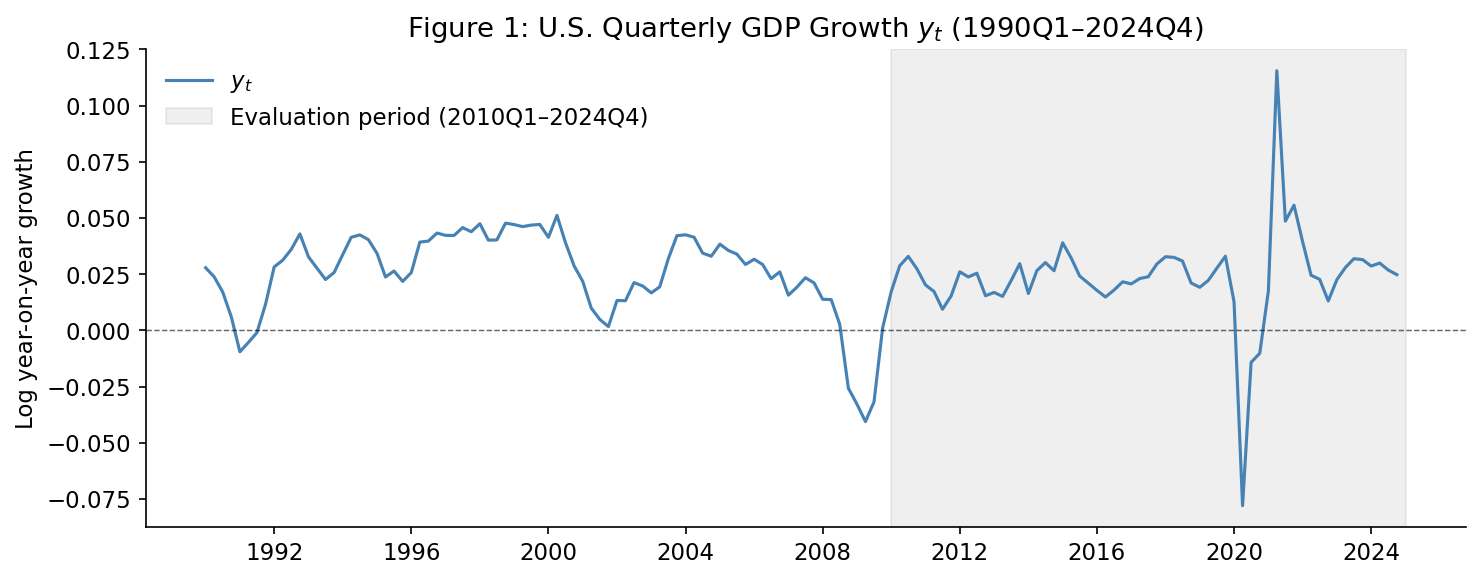

In [40]:
# Figure 1: Full-sample GDP growth with evaluation period shaded
fig, ax = plt.subplots(figsize=(10, 4))

dates_full     = df.index.to_timestamp()
eval_start_ts  = pd.Period(EVAL_START, "Q").to_timestamp()
eval_end_ts    = pd.Period(EVAL_END,   "Q").to_timestamp(how="end")

ax.plot(dates_full, df["y"], color="steelblue", linewidth=1.5, label="$y_t$")
ax.axvspan(eval_start_ts, eval_end_ts,
           alpha=0.12, color="grey", label="Evaluation period (2010Q1–2024Q4)")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Figure 1: U.S. Quarterly GDP Growth $y_t$ (1990Q1–2024Q4)")
ax.set_ylabel("Log year-on-year growth")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/fig1_gdp_growth.pdf", bbox_inches="tight")
plt.show()

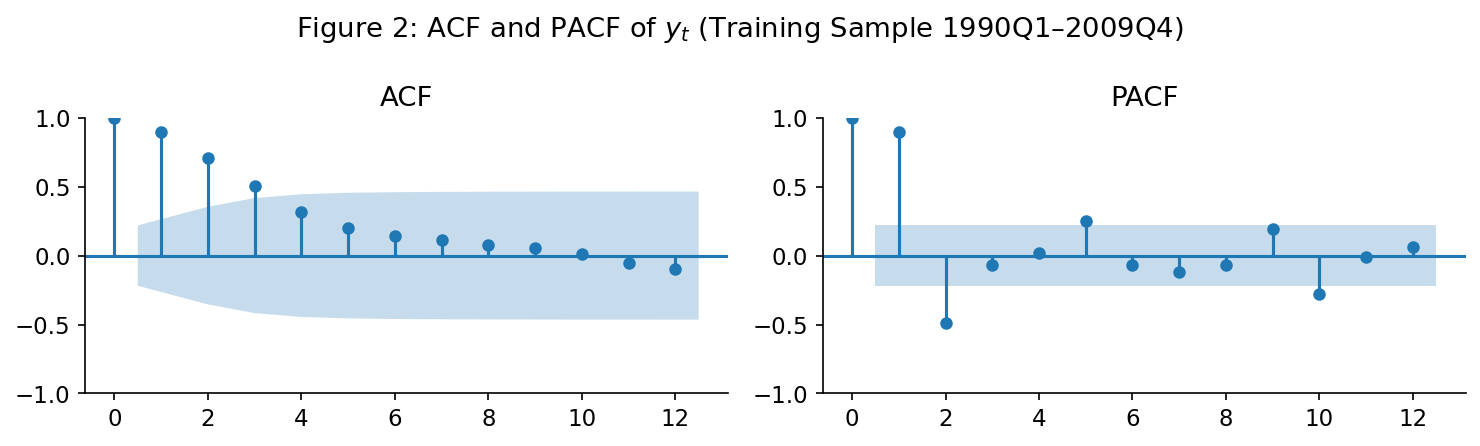

In [41]:
# Figure 2: ACF and PACF on training sample
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf( train, lags=12, ax=axes[0], title="ACF")
plot_pacf(train, lags=12, ax=axes[1], title="PACF")
fig.suptitle("Figure 2: ACF and PACF of $y_t$ (Training Sample 1990Q1–2009Q4)")
plt.tight_layout()
plt.savefig("figures/fig2_acf_pacf.pdf", bbox_inches="tight")
plt.show()

## 3. Model Selection & Estimation

Estimate AR(1)–AR(4) via OLS and ARMA(1,1) via ML.  
Compare using AIC and BIC → **Table 1**.

In [20]:
# Estimate AR(1)–AR(4) and ARMA(1,1) on training sample
# Store results in a dict keyed by model label
model_specs = {
    "AR(1)":     (1, 0, 0),
    "AR(2)":     (2, 0, 0),
    "AR(3)":     (3, 0, 0),
    "AR(4)":     (4, 0, 0),
    "ARMA(1,1)": (1, 0, 1),
}
fitted_models = {}
for label, (p, d, q) in model_specs.items():
    res = ARIMA(train, order=(p, d, q), trend="c").fit()
    fitted_models[label] = res

# Table 1: AIC, BIC, sigma-hat, Ljung-Box p-value (lag 8)
rows = []
for label, res in fitted_models.items():
    lb_pval = acorr_ljungbox(res.resid, lags=[8], return_df=True)["lb_pvalue"].values[0]
    rows.append({
        "Model": label,
        "AIC": round(res.aic, 2),
        "BIC": round(res.bic, 2),
        "σ̂": round(np.sqrt(res.params.get("sigma2", np.nan)), 4),
        "LB p-val (lag 8)": round(lb_pval, 3),
    })

table1 = pd.DataFrame(rows).set_index("Model")
print("Table 1: Model Comparison")
print(table1.to_string())

Table 1: Model Comparison
              AIC     BIC      σ̂  LB p-val (lag 8)
Model                                              
AR(1)     -535.78 -528.64  0.0081             0.002
AR(2)     -551.86 -542.33  0.0072             0.140
AR(3)     -552.15 -540.24  0.0071             0.239
AR(4)     -550.23 -535.94  0.0071             0.285
ARMA(1,1) -546.13 -536.60  0.0075             0.117


In [21]:
# Select preferred model based on Table 1:
# AR(2) has the best BIC (most parsimonious criterion) and its AIC is virtually
# identical to AR(3). AR(1) is rejected — Ljung-Box p=0.002 signals residual
# autocorrelation; AR(3) adds one unnecessary parameter over AR(2).
PREFERRED_LABEL = "AR(2)"
preferred = fitted_models[PREFERRED_LABEL]
print(preferred.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 279.930
Date:                Sat, 07 Mar 2026   AIC                           -551.860
Time:                        12:02:21   BIC                           -542.332
Sample:                    03-31-1990   HQIC                          -548.040
                         - 12-31-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0262      0.006      4.345      0.000       0.014       0.038
ar.L1          1.3587      0.123     11.005      0.000       1.117       1.601
ar.L2         -0.5118      0.124     -4.124      0.0

In [22]:
from scipy.stats import chi2 as chi2_dist

# GETS reduction: top-down from AR(4) using LR tests
# LR stat: xi_LR = -2*(logL_restricted - logL_unrestricted) ~ chi^2(j)
# H0: restricted model is the DGP (j = number of restrictions dropped)
# Fail to reject => accept the restriction and reduce.
# (Course 02_DynamicModels §6: "General-to-Specific principle: start with a
#  large model and reduce. The opposite is dangerous.")

gets_pairs = [
    ("AR(3)", "AR(4)", 1),   # H0: phi_4 = 0  (AR(4) -> AR(3))
    ("AR(2)", "AR(3)", 1),   # H0: phi_3 = 0  (AR(3) -> AR(2))
]

print("GETS Reduction: LR Tests (starting from AR(4))")
print(f"  {'H0 (restricted)':<14}  {'H1 (unrestricted)':<16}  j  {'LR stat':>8}  {'p-value':>8}  Decision")
print("  " + "-" * 70)
for restricted, unrestricted, j in gets_pairs:
    ll_r    = fitted_models[restricted].llf
    ll_u    = fitted_models[unrestricted].llf
    lr_stat = -2 * (ll_r - ll_u)
    p_val   = chi2_dist.sf(lr_stat, df=j)
    decision = "Fail to reject -> reduce" if p_val >= 0.05 else "Reject -> retain"
    print(f"  {restricted:<14}  {unrestricted:<16}  {j}  {lr_stat:>8.3f}  {p_val:>8.3f}  {decision}")

# Joint test: AR(4) -> AR(2) directly (j=2)
lr_joint = -2 * (fitted_models["AR(2)"].llf - fitted_models["AR(4)"].llf)
p_joint  = chi2_dist.sf(lr_joint, df=2)
print(f"\n  AR(4) -> AR(2) joint (j=2):  LR = {lr_joint:.3f},  p = {p_joint:.3f}")
print(f"\nGETS outcome: AR(2) -- the sequential reductions from AR(4) are not rejected.")


GETS Reduction: LR Tests (starting from AR(4))
  H0 (restricted)  H1 (unrestricted)  j   LR stat   p-value  Decision
  ----------------------------------------------------------------------
  AR(3)           AR(4)             1     0.077     0.781  Fail to reject -> reduce
  AR(2)           AR(3)             1     2.291     0.130  Fail to reject -> reduce

  AR(4) -> AR(2) joint (j=2):  LR = 2.369,  p = 0.306

GETS outcome: AR(2) -- the sequential reductions from AR(4) are not rejected.


## 4. Misspecification Testing

Run on preferred model residuals **before** interpreting coefficients.

| Test | H₀ | Lags / details |
|---|---|---|
| Ljung-Box | No serial autocorrelation | lags 4, 8 |
| Jarque-Bera | Residuals are normally distributed | — |
| ARCH-LM | No conditional heteroskedasticity | lags 4 |

In [23]:
resid = preferred.resid.dropna()

# Ljung-Box at lags 4 and 8
# model_df=2 subtracts the 2 estimated AR parameters so the null is chi^2(h-p)
# (Course 02B_Misspecification: "xi_LB ~ chi^2(h-p) under H0, p = AR+MA terms")
lb = acorr_ljungbox(resid, lags=[4, 8], return_df=True, model_df=2)
print("Ljung-Box test (df adjusted for 2 AR parameters: null ~ chi2(h-2)):")
print(lb[["lb_stat", "lb_pvalue"]].rename(columns={"lb_stat": "LB stat", "lb_pvalue": "p-value"}))

# Jarque-Bera normality test
jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(resid)
excess_kurt = jb_kurt - 3
print(f"\nJarque-Bera: stat={jb_stat:.3f}, p-value={jb_pval:.3f}")
print(f"  Skewness={jb_skew:.3f},  Excess kurtosis={excess_kurt:.3f}")

# ARCH-LM test (lags 4)
arch_stat, arch_pval, _, _ = het_arch(resid, nlags=4)
print(f"ARCH-LM (lag 4): stat={arch_stat:.3f}, p-value={arch_pval:.3f}")


Ljung-Box test (df adjusted for 2 AR parameters: null ~ chi2(h-2)):
     LB stat   p-value
4   8.670093  0.013101
8  12.254265  0.056531

Jarque-Bera: stat=8.633, p-value=0.013
  Skewness=-0.469,  Excess kurtosis=1.308
ARCH-LM (lag 4): stat=7.976, p-value=0.092


In [24]:
# Intervention dummy diagnostic: does a GFC dummy absorb the JB rejection?
# Course (02B_Misspecification): "We may include an intervention dummy for
# outliers: d_t = 1(t=T_0)."
# DIAGNOSTIC ONLY — this model is NOT used for forecasting.

gfc_dummies = pd.DataFrame(
    {
        "d_2008Q4": (train.index == pd.Period("2008Q4", "Q")).astype(float),
        "d_2009Q1": (train.index == pd.Period("2009Q1", "Q")).astype(float),
    },
    index=train.index,
)

preferred_gfc = ARIMA(train, order=(2, 0, 0), trend="c", exog=gfc_dummies).fit()
resid_gfc = preferred_gfc.resid.dropna()
jb_stat_d, jb_pval_d, _, jb_kurt_d = jarque_bera(resid_gfc)

print("AR(2) + GFC intervention dummies (diagnostic only)")
print(f"  d_2008Q4: coef={preferred_gfc.params['d_2008Q4']:.4f},  t={preferred_gfc.tvalues['d_2008Q4']:.2f}")
print(f"  d_2009Q1: coef={preferred_gfc.params['d_2009Q1']:.4f},  t={preferred_gfc.tvalues['d_2009Q1']:.2f}")
print(f"\nJarque-Bera without dummies: stat={jb_stat:.3f}, p={jb_pval:.3f}, excess kurt={excess_kurt:.3f}")
print(f"Jarque-Bera with    dummies: stat={jb_stat_d:.3f}, p={jb_pval_d:.3f}, excess kurt={jb_kurt_d - 3:.3f}")
if jb_pval_d >= 0.05:
    print("-> Normality not rejected once GFC outliers absorbed: JB rejection was outlier-driven.")
else:
    print("-> Normality still rejected with dummies: fat tails are not solely due to GFC outliers.")


AR(2) + GFC intervention dummies (diagnostic only)
  d_2008Q4: coef=-0.0113,  t=-4.11
  d_2009Q1: coef=-0.0014,  t=-0.37

Jarque-Bera without dummies: stat=8.633, p=0.013, excess kurt=1.308
Jarque-Bera with    dummies: stat=0.257, p=0.879, excess kurt=-0.245
-> Normality not rejected once GFC outliers absorbed: JB rejection was outlier-driven.


In [25]:
# Table 2: Preferred model estimates
params = preferred.params
bse   = preferred.bse
tstat = preferred.tvalues
pvals = preferred.pvalues

table2 = pd.DataFrame({
    "Coefficient": params,
    "Std. Error": bse,
    "t-stat": tstat,
    "p-value": pvals,
}).round(4)
print(f"Table 2: {PREFERRED_LABEL} Estimation Results (1990Q1–2009Q4)")
print(table2.to_string())

Table 2: AR(2) Estimation Results (1990Q1–2009Q4)
        Coefficient  Std. Error   t-stat  p-value
const        0.0262      0.0060   4.3455      0.0
ar.L1        1.3587      0.1235  11.0055      0.0
ar.L2       -0.5118      0.1241  -4.1237      0.0
sigma2       0.0001      0.0000   6.5740      0.0


## 5. Forecasting (2010Q1–2024Q4)

Produce one-step-ahead forecasts using **fixed** training-sample parameters with recursive residual updates (per ARMA forecasting formula).  
Compare against `forecast_naive` via RMSE and Diebold-Mariano test → **Figure 3**, **Table 3**.

In [26]:
# One-step-ahead forecasts using FIXED training-sample parameters
# Implements the recursive formula from forecasting_with_ARMA.tex.
#
# IMPORTANT: statsmodels ARIMA(trend='c') stores params["const"] as the
# UNCONDITIONAL MEAN mu, NOT the intercept delta.
# The model is: y_t = mu + phi_1*(y_{t-1}-mu) + phi_2*(y_{t-2}-mu) + eps_t
# Equivalently: y_t = delta_eff + phi_1*y_{t-1} + phi_2*y_{t-2} + eps_t
#   where delta_eff = mu * (1 - phi_1 - phi_2)
# So: E[y_t | I_{t-1}] = delta_eff + phi_1*y_{t-1} + phi_2*y_{t-2}

ar_coefs     = preferred.arparams            # [phi_1, ..., phi_p]
ma_coefs     = preferred.maparams            # [theta_1, ..., theta_q]  (empty for AR)
mu           = preferred.params["const"]     # unconditional mean
delta_eff    = mu * (1 - ar_coefs.sum())     # effective intercept
p            = len(ar_coefs)
q            = len(ma_coefs)

# Full y series: train (1990Q1–2009Q4) + eval (2010Q1–2024Q4)
full_y_s = df.loc[:EVAL_END, "y"]
T_train  = len(train)                    # 80
y_arr    = full_y_s.values               # length 140

# Residual array: initialise with training-sample Kalman innovations
eps = np.zeros(len(y_arr))
eps[:T_train] = preferred.resid.values   # ε̂_t for training period

# Compute conditional means recursively over the evaluation period
mu_full = np.full(len(y_arr), np.nan)

for t in range(T_train, len(y_arr)):      # t = 80, 81, ..., 139
    mu_t = delta_eff
    for i in range(p):                    # AR terms
        mu_t += ar_coefs[i] * y_arr[t - 1 - i]
    for j in range(q):                    # MA terms (empty for AR models)
        mu_t += ma_coefs[j] * eps[t - 1 - j]
    mu_full[t] = mu_t
    eps[t] = y_arr[t] - mu_t             # update residual for next step

forecast_model = pd.Series(
    mu_full[T_train:T_train + 60],
    index=eval_y.index,
    name="forecast_model",
)

print(f"mu={mu:.4f}  delta_eff={delta_eff:.5f}  AR={np.round(ar_coefs,4)}")
print(f"Forecast obs     : {len(forecast_model)}")
print(forecast_model.head())

mu=0.0262  delta_eff=0.00400  AR=[ 1.3587 -0.5118]
Forecast obs     : 60
2010Q1    0.021725
2010Q2    0.026971
2010Q3    0.034170
2010Q4    0.034000
2011Q1    0.024371
Freq: Q-DEC, Name: forecast_model, dtype: float64


In [27]:
import statsmodels.api as sm

# Forecast evaluation: RMSE and Diebold-Mariano test
e_model = eval_y.values - forecast_model.values
e_naive = eval_y.values - forecast_naive.values

rmse_model = np.sqrt(np.mean(e_model**2))
rmse_naive = np.sqrt(np.mean(e_naive**2))

# Diebold-Mariano test with HAC standard error (H0: E[d_t]=0, equal MSE)
# Course (02_DynamicModels §7): "d_t is typically autocorrelated; s.e.(d̄) should
# use a HAC variance estimator. Implementation: regress d_t on a constant."
# Newey-West with 1 lag (standard for one-step-ahead forecast errors).
d      = e_model**2 - e_naive**2
T_eval = len(d)
dm_ols  = sm.OLS(d, np.ones(T_eval)).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
dm_stat = dm_ols.tvalues[0]
dm_pval = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

# Table 3
table3 = pd.DataFrame(
    {
        "Model":           [PREFERRED_LABEL,    "Naive"],
        "RMSE":            [round(rmse_model, 4), round(rmse_naive, 4)],
        "DM statistic":    [f"{dm_stat:.3f}",     "—"],
        "DM p-value":      [f"{dm_pval:.3f}",     "—"],
    }
).set_index("Model")

print("Table 3: Forecast Evaluation (2010Q1–2024Q4)")
print(table3.to_string())


Table 3: Forecast Evaluation (2010Q1–2024Q4)
         RMSE DM statistic DM p-value
Model                                
AR(2)  0.0256        1.186      0.236
Naive  0.0206            —          —


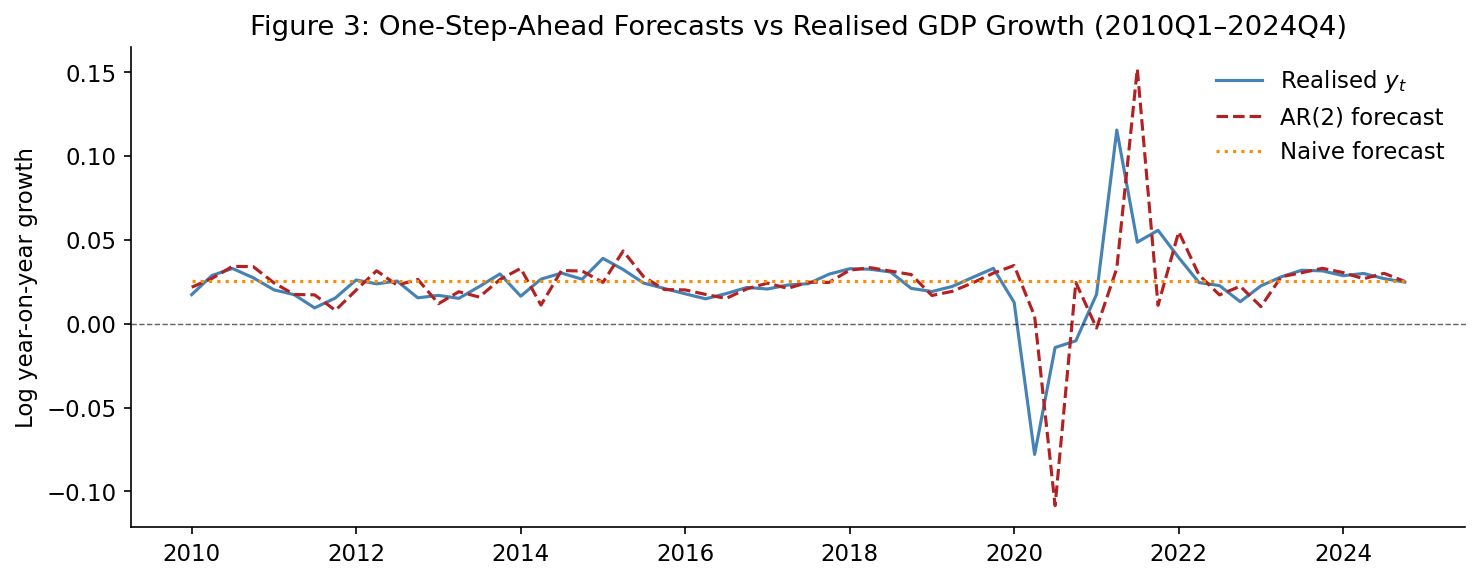

In [48]:
# Figure 3: Realised y_t vs model forecast vs naive forecast (eval period)
fig, ax = plt.subplots(figsize=(10, 4))
dates_eval = eval_y.index.to_timestamp()

ax.plot(dates_eval, eval_y.values,         color="steelblue",  linewidth=1.5,
        label="Realised $y_t$")
ax.plot(dates_eval, forecast_model.values, color="firebrick",   linewidth=1.5,
        linestyle="--", label=f"{PREFERRED_LABEL} forecast")
ax.plot(dates_eval, forecast_naive.values, color="darkorange",  linewidth=1.5,
        linestyle=":",  label="Naive forecast")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Figure 3: One-Step-Ahead Forecasts vs Realised GDP Growth (2010Q1–2024Q4)")
ax.set_ylabel("Log year-on-year growth")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/fig3_forecasts.pdf", bbox_inches="tight")
plt.show()

## 6. Growth-at-Risk (2010Q1–2024Q4)

$$\widehat{\text{GaR}}^{0.1}_t = \hat{\mu}_t + \hat{\sigma} \cdot \Phi^{-1}(0.1)$$

Evaluate via violation rate, t-test for correct coverage (H₀: $E[\text{hit}_t]=0.1$), and tick loss → **Figure 4**, **Table 4**.

In [49]:
# Compute GaR estimates
# GaR^alpha_t = mu_t + sigma * Phi^{-1}(alpha)
sigma_hat = np.sqrt(preferred.params["sigma2"])
phi_inv   = stats.norm.ppf(ALPHA)          # Phi^{-1}(0.10) ≈ −1.282

GaR_model = forecast_model + sigma_hat * phi_inv

print(f"σ̂             = {sigma_hat:.4f}")
print(f"Φ⁻¹(0.10)     = {phi_inv:.4f}")
print(f"\nModel GaR (first 5):\n{GaR_model.head()}")
print(f"\nGaR_np (first 5):\n{GaR_np.head()}")

σ̂             = 0.0072
Φ⁻¹(0.10)     = -1.2816

Model GaR (first 5):
2010Q1    0.012490
2010Q2    0.017735
2010Q3    0.024934
2010Q4    0.024764
2011Q1    0.015135
Freq: Q-DEC, Name: forecast_model, dtype: float64

GaR_np (first 5):
2010Q1    0.00161
2010Q2    0.00161
2010Q3    0.00161
2010Q4    0.00161
2011Q1    0.00161
Freq: Q-DEC, Name: GaR_np, dtype: float64


In [50]:
# GaR evaluation: violation rate, coverage t-test, and tick loss
def evaluate_gar(y, gar, label="Model"):
    hit   = (y.values < gar.values).astype(float)
    p_hat = hit.mean()
    T     = len(hit)
    # t-test: H0: E[hit_t] = alpha
    se     = np.sqrt(ALPHA * (1 - ALPHA) / T)
    t_stat = (p_hat - ALPHA) / se
    t_pval = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    # Tick loss: T_alpha(y_t, GaR_t) = (alpha - hit_t)(y_t - GaR_t)
    tick  = ((ALPHA - hit) * (y.values - gar.values)).mean()
    return p_hat, t_stat, t_pval, tick

model_res = evaluate_gar(eval_y, GaR_model, label=f"{PREFERRED_LABEL} GaR")
np_res    = evaluate_gar(eval_y, GaR_np,    label="GaR_np (naive)")

# Table 4
table4 = pd.DataFrame(
    {
        "GaR series":               [f"{PREFERRED_LABEL} GaR", "GaR_np (naive)"],
        "Violation rate p̂":         [round(model_res[0], 3), round(np_res[0], 3)],
        "t-stat (H₀: p̂ = 0.10)":   [round(model_res[1], 3), round(np_res[1], 3)],
        "p-value":                  [round(model_res[2], 3), round(np_res[2], 3)],
        "Mean tick loss":           [round(model_res[3], 6), round(np_res[3], 6)],
    }
).set_index("GaR series")

print("Table 4: GaR Evaluation at 10% Level (2010Q1–2024Q4)")
print(table4.to_string())

Table 4: GaR Evaluation at 10% Level (2010Q1–2024Q4)
                Violation rate p̂  t-stat (H₀: p̂ = 0.10)  p-value  Mean tick loss
GaR series                                                                        
AR(2) GaR                    0.15                   1.291    0.197         0.00458
GaR_np (naive)               0.05                  -1.291    0.197         0.00399


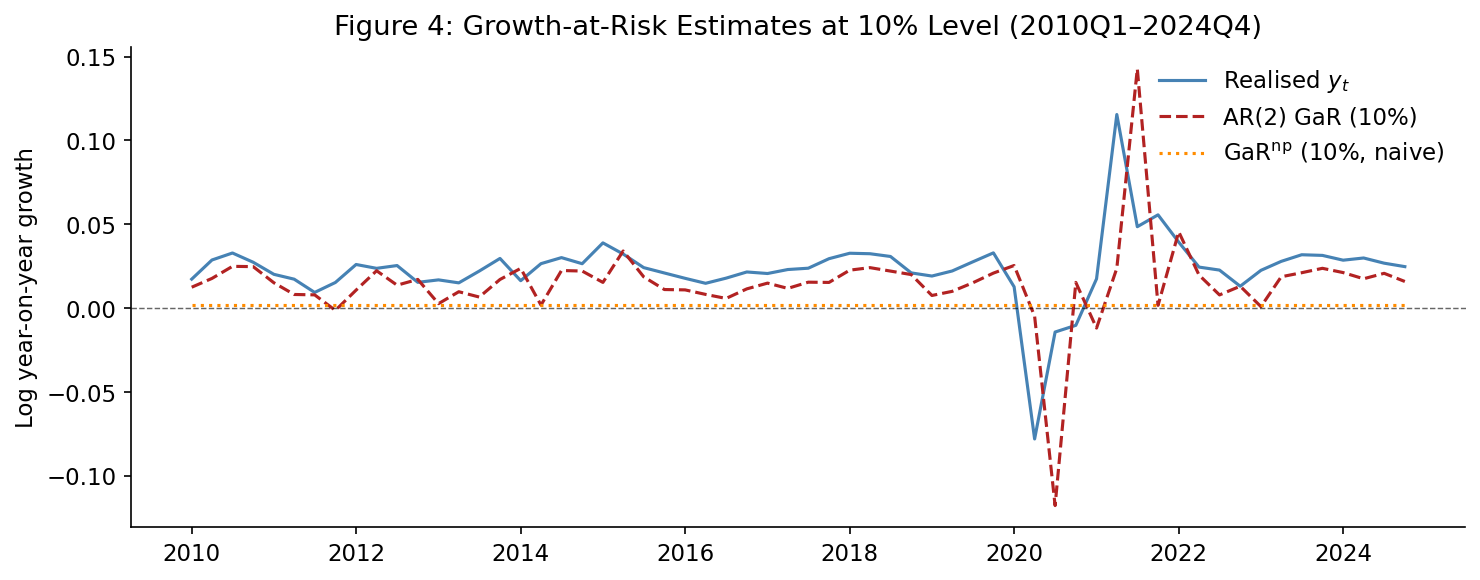

In [51]:
# Figure 4: Realised y_t vs model GaR vs GaR_np (eval period)
fig, ax = plt.subplots(figsize=(10, 4))
dates_eval = eval_y.index.to_timestamp()

ax.plot(dates_eval, eval_y.values,    color="steelblue",  linewidth=1.5,
        label="Realised $y_t$")
ax.plot(dates_eval, GaR_model.values, color="firebrick",  linewidth=1.5,
        linestyle="--", label=f"{PREFERRED_LABEL} GaR (10%)")
ax.plot(dates_eval, GaR_np.values,    color="darkorange", linewidth=1.5,
        linestyle=":",  label=r"GaR$^{\mathrm{np}}$ (10%, naive)")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Figure 4: Growth-at-Risk Estimates at 10% Level (2010Q1–2024Q4)")
ax.set_ylabel("Log year-on-year growth")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/fig4_gar.pdf", bbox_inches="tight")
plt.show()

## 7. Export Figures & Tables

All figures are saved to `figures/` (PDF, publication quality).  
Run the cell below to export tables as LaTeX `.tex` snippets → `\input{}` them in `assignment1.tex`.

In [52]:
import os
os.makedirs("tables", exist_ok=True)

def df_to_latex(df, caption, label, float_fmt="{:.4f}"):
    """Write a DataFrame to a self-contained LaTeX table (no jinja2 required)."""
    cols = " & ".join(df.columns) if df.columns.tolist() else ""
    header = f"  {df.index.name or ''} & {cols} \\\\\n  \\midrule\n" if cols else ""

    rows = []
    for idx, row in df.iterrows():
        cells = [str(idx)]
        for v in row:
            try:
                cells.append(float_fmt.format(float(v)))
            except (ValueError, TypeError):
                cells.append(str(v))
        rows.append("  " + " & ".join(cells) + " \\\\")

    n_cols = len(df.columns) + 1
    col_spec = "l" + "r" * len(df.columns)

    tex = (
        f"\\begin{{table}}[H]\n"
        f"  \\centering\n"
        f"  \\caption{{{caption}}}\n"
        f"  \\label{{{label}}}\n"
        f"  \\begin{{tabular}}{{{col_spec}}}\n"
        f"  \\toprule\n"
        f"{header}"
        + "\n".join(rows) + "\n"
        f"  \\bottomrule\n"
        f"  \\end{{tabular}}\n"
        f"\\end{{table}}\n"
    )
    return tex

# Write each table
tables_to_export = {
    "tables/table1_selection.tex": (
        table1,
        "Model comparison: AIC, BIC, $\\hat{{\\sigma}}$, and Ljung-Box p-value (training sample 1990Q1--2009Q4).",
        "tab:model_selection",
        "{:.2f}",
    ),
    "tables/table2_estimates.tex": (
        table2,
        f"Estimation results for the {PREFERRED_LABEL} model (training sample 1990Q1--2009Q4).",
        "tab:estimates",
        "{:.4f}",
    ),
    "tables/table3_forecast.tex": (
        table3,
        "Forecast evaluation: RMSE and Diebold-Mariano test (2010Q1--2024Q4).",
        "tab:forecast_eval",
        "{:.4f}",
    ),
    "tables/table4_gar.tex": (
        table4,
        "GaR evaluation at 10\\% level: violation rates, coverage test, and tick loss (2010Q1--2024Q4).",
        "tab:gar_eval",
        "{:.4f}",
    ),
}

for path, (tbl, cap, lbl, fmt) in tables_to_export.items():
    tex = df_to_latex(tbl, cap, lbl, fmt)
    with open(path, "w") as f:
        f.write(tex)
    print(f"Exported: {path}")

print("\nAll tables exported.")

Exported: tables/table1_selection.tex
Exported: tables/table2_estimates.tex
Exported: tables/table3_forecast.tex
Exported: tables/table4_gar.tex

All tables exported.
